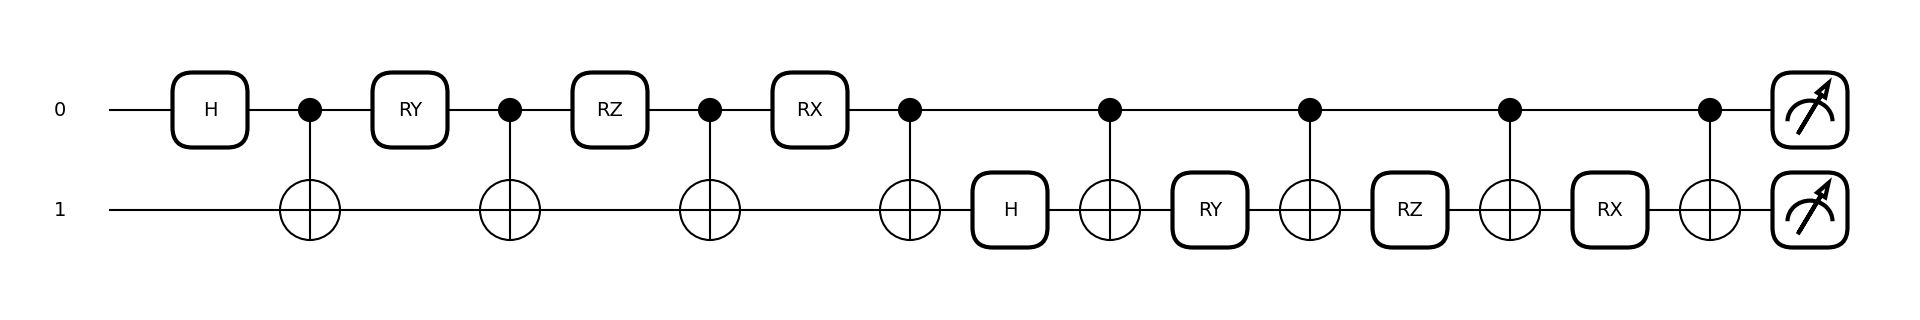

In [1]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv(r'C:\Users\NIT\Desktop\PAPER FINALIZED WORK BAND 2D DT-25-02-2025\DATASET\2D electronic properties2.csv',encoding='ISO-8859–1')       
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]

# Splitting the dataset into training and test set.  
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.06, random_state=2)  

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

# Quantum setup
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[0, 1])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [2]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)

# Sample test data

X_test_scaled = scaler.transform(x_test)

# Compute the test kernel matrix (train-test kernel)
K_test = np.zeros((len(X_test_scaled), len(X_train_scaled)))
for i in range(len(X_test_scaled)):
    for j in range(len(X_train_scaled)):
        K_test[i, j] = quantum_kernel(X_test_scaled[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred = svr.predict(K_test)
print("Predicted values:", y_pred)

Predicted values: [1.24526068 0.64667918 1.88692619 1.66798045 4.28170691 3.14844671
 0.83196986 3.41070793 3.34948568 2.85607579 0.6709445  1.61641788
 2.41380249 2.14521136 2.31436789 0.31795649 2.3203742  3.94250832
 1.12234642 2.02511242 1.78852221 2.57851987 1.17668648 1.10873542
 0.57299837 2.24445275 2.84379622 0.77819721 0.63552165 1.92184878
 0.70543662 1.82857593 1.44399791 0.98202564 4.00828819 2.03614467
 1.92430087 2.08920641 0.42114207 1.32918318 1.46753427 3.86761628
 0.37239686 1.62614728 0.5238364  3.14916046 4.4372111  1.1361642
 1.3915515  0.47412495 0.77579908 3.54216033 2.17914989 3.63965035
 1.32691408 2.0885181  0.73475275 1.56998662 1.31906519 1.08119615
 0.76147431 1.04632614 0.40896016 2.75033271 1.56251475 0.81609989
 0.69574927 1.44165485 1.17485697 0.71078752 1.75614422 2.41286819
 0.43004898 0.87226051 0.82067266 2.27559208 2.16770154 3.04593559
 1.07593831 0.82456814 0.74134284 3.49931678 1.08657375 0.8263462
 3.22704008]


train r^2: 0.39973260449762793
train MAE 0.7818886983232953
train RMSE: 1.0959635122095006


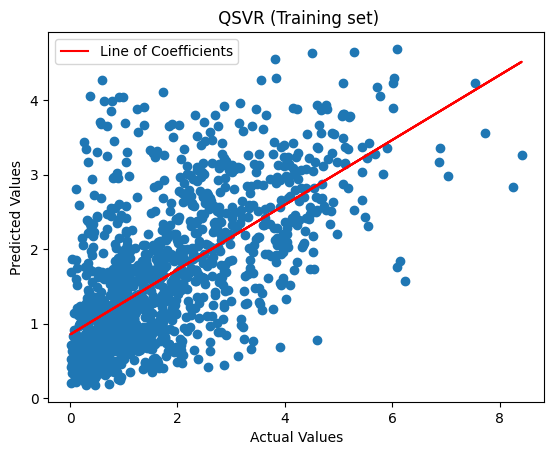

In [3]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QSVR (Training set)")#title
plt.legend()

Model evaluation - Test Set:
r^2: 0.5397114396270501
MAE 0.6247672161405055
RMSE: 0.8850239132767319


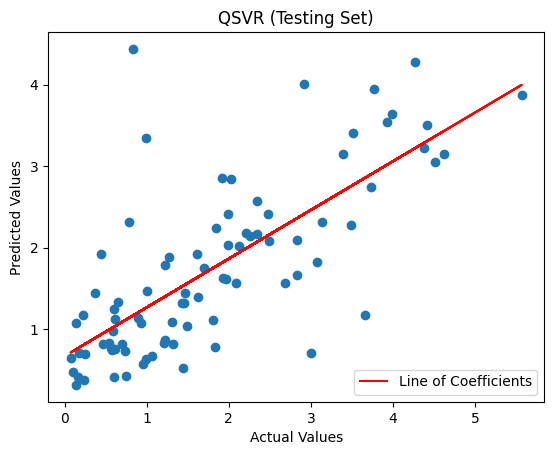

In [4]:
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
print("Model evaluation - Test Set:")
print('r^2:',r2_score(y_test, y_pred))
print('MAE', mean_absolute_error(y_test, y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))
# Plot straight line
plt.scatter(y_test, y_pred)
coefficients = np.polyfit(y_test, y_pred, 1)
line = np.polyval(coefficients, y_test)
plt.plot(y_test, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_test, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_test, y_pred)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_test, y_pred))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_test, y_pred)), (-0.2, 13.2))
plt.title("QSVR (Testing Set)")#title
plt.legend()


QUANTUM KERNEL ANALYSIS
Number of training samples : 1317
Number of test samples     : 85
Number of qubits           : 2

KERNEL CONCENTRATION
Mean diagonal             : 1.00000000
Mean off-diagonal         : 0.51053307
Std off-diagonal          : 0.31668537
Diagonal dominance        : 1.95873698
Distance from identity    : 21.79423479
Frobenius norm            : 791.75569370

SPECTRAL ANALYSIS
Maximum eigenvalue        : 739.05257671
Minimum eigenvalue        : 0.00000000
Condition number          : 2.95091787e+02
Near-zero eigenvalue frac.: 0.99316629
Spectral entropy          : 1.39607585
Effective dimension       : 2.76687258
Effective rank            : 4.03931795
Effective rank ratio      : 0.00306706
Top-1 concentration       : 0.56116369
Top-5 concentration       : 0.94698155
Top-10 concentration      : 1.00000000

TEST KERNEL
Mean test kernel    : 0.48566726
Std test kernel     : 0.31742030


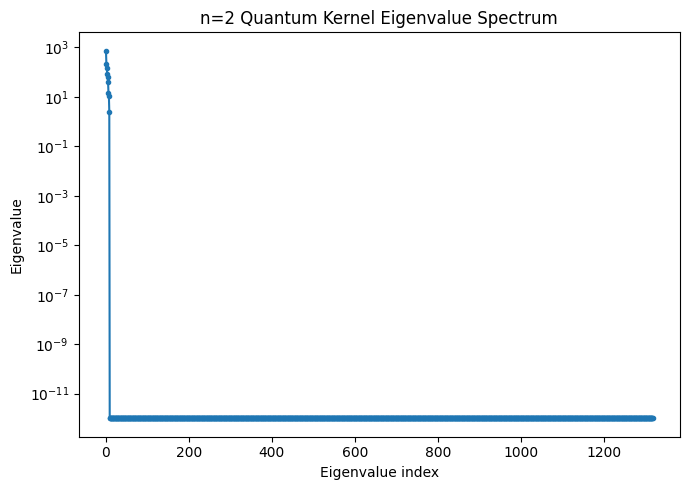

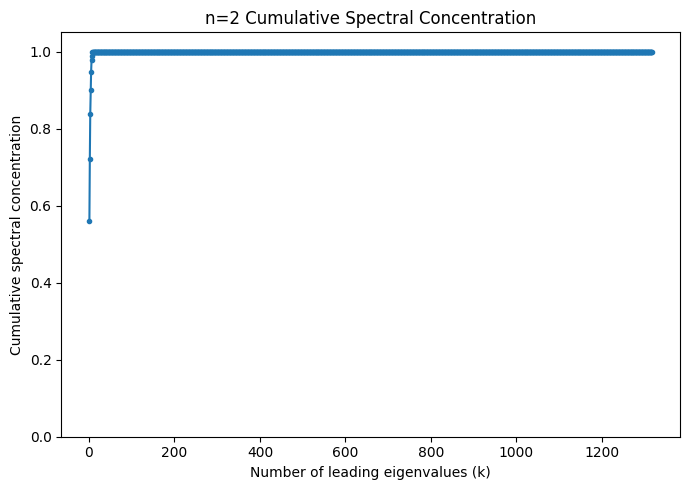

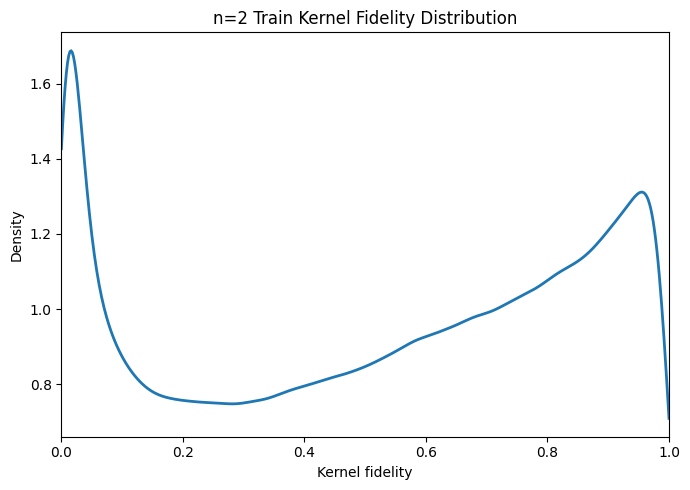

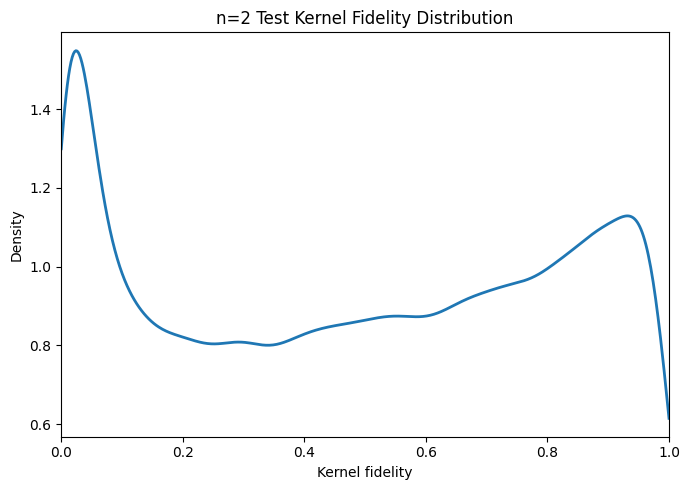

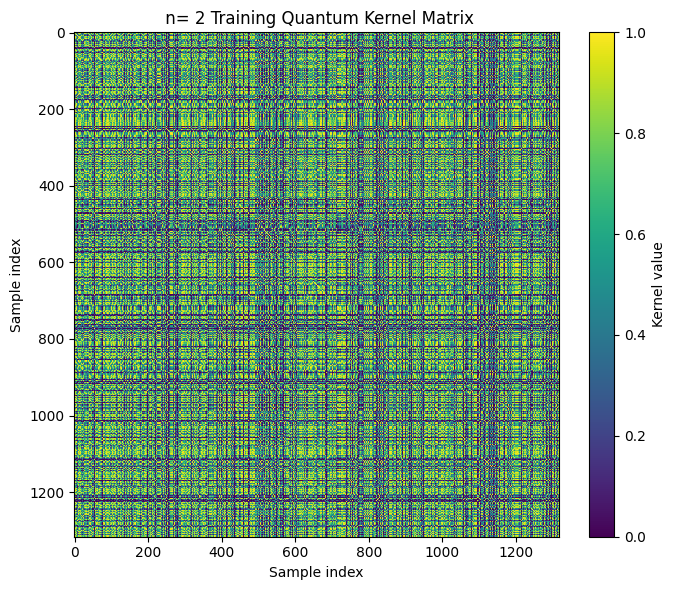

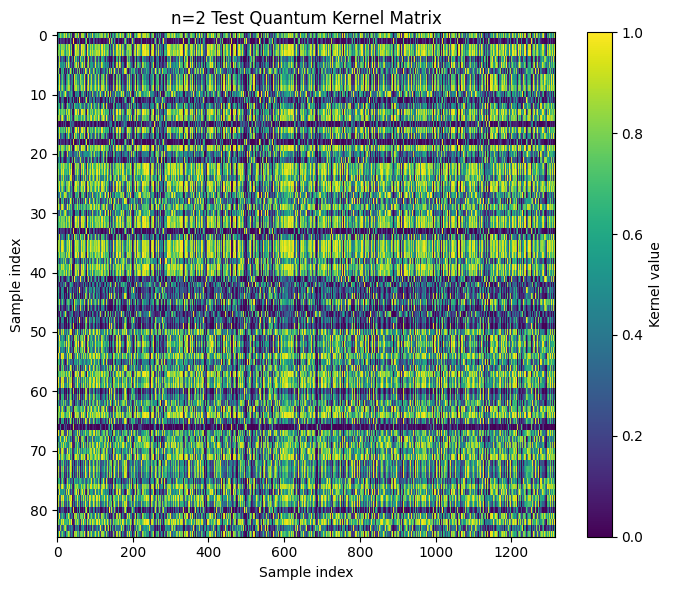


FINAL KERNEL ANALYSIS TABLE
                    Parameter               Value
             Number of qubits                   2
             Training samples                1317
                Mean diagonal  0.9999999999999993
            Mean off-diagonal   0.510533067777025
             Std off-diagonal 0.31668537476268616
           Diagonal dominance  1.9587369812384978
       Distance from identity           21.794235
               Frobenius norm          791.755694
           Maximum eigenvalue          739.052577
           Minimum eigenvalue                 0.0
             Condition number          295.091787
Near-zero eigenvalue fraction            0.993166
             Spectral entropy            1.396076
          Effective dimension            2.766873
               Effective rank            4.039318
         Effective rank ratio            0.003067
 Top-1 spectral concentration            0.561164
 Top-5 spectral concentration            0.946982
Top-10 spectral conce

In [6]:
# ============================================================
# QUANTUM KERNEL COMPLEXITY AND CONCENTRATION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde


# ============================================================
# 1. BASIC INFORMATION
# ============================================================

N = K_train.shape[0]

print("\n==============================================")
print("QUANTUM KERNEL ANALYSIS")
print("==============================================")

print("Number of training samples :", N)
print("Number of test samples     :", K_test.shape[0])
print("Number of qubits           :", n_qubits)


# ============================================================
# 2. DIAGONAL AND OFF-DIAGONAL VALUES
# ============================================================

diagonal_values = np.diag(K_train)

off_diagonal_values = K_train[
    np.triu_indices(N, k=1)
]

mean_diagonal = np.mean(
    diagonal_values
)

mu_off = np.mean(
    off_diagonal_values
)

sigma_off = np.std(
    off_diagonal_values
)


# ============================================================
# 3. DIAGONAL DOMINANCE
# ============================================================

if mu_off > 0:
    diagonal_dominance = (
        mean_diagonal / mu_off
    )
else:
    diagonal_dominance = np.inf


# ============================================================
# 4. DISTANCE FROM IDENTITY
# ============================================================

I = np.eye(N)

identity_distance = (
    np.linalg.norm(
        K_train - I,
        ord='fro'
    )
    /
    np.linalg.norm(
        I,
        ord='fro'
    )
)


# ============================================================
# 5. FROBENIUS NORM
# ============================================================

frobenius_norm = np.linalg.norm(
    K_train,
    ord='fro'
)


# ============================================================
# 6. EIGENVALUE SPECTRUM
# ============================================================

eigenvalues = np.linalg.eigvalsh(
    K_train
)

# Largest to smallest
eigenvalues = np.sort(
    eigenvalues
)[::-1]

# Remove tiny numerical negative values
eigenvalues = np.clip(
    eigenvalues,
    0,
    None
)

lambda_max = eigenvalues[0]

lambda_min = eigenvalues[-1]


# ============================================================
# 7. CONDITION NUMBER
# ============================================================

threshold = 1e-12

positive_eigenvalues = eigenvalues[
    eigenvalues > threshold
]

if len(positive_eigenvalues) > 0:

    condition_number = (
        np.max(positive_eigenvalues)
        /
        np.min(positive_eigenvalues)
    )

else:

    condition_number = np.inf


# ============================================================
# 8. NEAR-ZERO EIGENVALUES
# ============================================================

number_small = np.sum(
    eigenvalues <= threshold
)

fraction_small = (
    number_small / N
)


# ============================================================
# 9. NORMALIZED EIGENVALUES
# ============================================================

total_eigenvalue = np.sum(
    eigenvalues
)

p = (
    eigenvalues /
    total_eigenvalue
)

p_nonzero = p[
    p > threshold
]


# ============================================================
# 10. SPECTRAL ENTROPY
# ============================================================

spectral_entropy = -np.sum(
    p_nonzero *
    np.log(p_nonzero)
)


# ============================================================
# 11. EFFECTIVE RANK
# ============================================================

effective_rank = np.exp(
    spectral_entropy
)


# ============================================================
# 12. EFFECTIVE RANK RATIO
# ============================================================

effective_rank_ratio = (
    effective_rank / N
)


# ============================================================
# 13. EFFECTIVE DIMENSION
# Participation-ratio definition
# ============================================================

effective_dimension = (
    total_eigenvalue ** 2
    /
    np.sum(eigenvalues ** 2)
)


# ============================================================
# 14. SPECTRAL CONCENTRATION
# ============================================================

SC1 = (
    np.sum(eigenvalues[:1])
    /
    total_eigenvalue
)

SC5 = (
    np.sum(eigenvalues[:5])
    /
    total_eigenvalue
)

SC10 = (
    np.sum(eigenvalues[:10])
    /
    total_eigenvalue
)


# ============================================================
# 15. TEST-TRAIN KERNEL STATISTICS
# ============================================================

test_values = K_test.flatten()

mu_test = np.mean(
    test_values
)

sigma_test = np.std(
    test_values
)


# ============================================================
# 16. PRINT ALL METRICS
# ============================================================

print("\n==============================================")
print("KERNEL CONCENTRATION")
print("==============================================")

print(
    f"Mean diagonal             : {mean_diagonal:.8f}"
)

print(
    f"Mean off-diagonal         : {mu_off:.8f}"
)

print(
    f"Std off-diagonal          : {sigma_off:.8f}"
)

print(
    f"Diagonal dominance        : {diagonal_dominance:.8f}"
)

print(
    f"Distance from identity    : {identity_distance:.8f}"
)

print(
    f"Frobenius norm            : {frobenius_norm:.8f}"
)


print("\n==============================================")
print("SPECTRAL ANALYSIS")
print("==============================================")

print(
    f"Maximum eigenvalue        : {lambda_max:.8f}"
)

print(
    f"Minimum eigenvalue        : {lambda_min:.8f}"
)

print(
    f"Condition number          : {condition_number:.8e}"
)

print(
    f"Near-zero eigenvalue frac.: {fraction_small:.8f}"
)

print(
    f"Spectral entropy          : {spectral_entropy:.8f}"
)

print(
    f"Effective dimension       : {effective_dimension:.8f}"
)

print(
    f"Effective rank            : {effective_rank:.8f}"
)

print(
    f"Effective rank ratio      : {effective_rank_ratio:.8f}"
)

print(
    f"Top-1 concentration       : {SC1:.8f}"
)

print(
    f"Top-5 concentration       : {SC5:.8f}"
)

print(
    f"Top-10 concentration      : {SC10:.8f}"
)


print("\n==============================================")
print("TEST KERNEL")
print("==============================================")

print(
    f"Mean test kernel    : {mu_test:.8f}"
)

print(
    f"Std test kernel     : {sigma_test:.8f}"
)


# ============================================================
# 17. EIGENVALUE SPECTRUM
# ============================================================

eigenvalues_plot = np.maximum(
    eigenvalues,
    1e-12
)

plt.figure(figsize=(7, 5))

plt.plot(
    np.arange(1, N + 1),
    eigenvalues_plot,
    marker='o',
    markersize=3
)

plt.yscale('log')

plt.xlabel(
    "Eigenvalue index"
)

plt.ylabel(
    "Eigenvalue"
)

plt.title(
    "n=2 Quantum Kernel Eigenvalue Spectrum"
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. CUMULATIVE SPECTRAL CONCENTRATION
# ============================================================

cumulative_SC = (
    np.cumsum(eigenvalues)
    /
    total_eigenvalue
)

plt.figure(figsize=(7, 5))

plt.plot(
    np.arange(1, N + 1),
    cumulative_SC,
    marker='o',
    markersize=3
)

plt.xlabel(
    "Number of leading eigenvalues (k)"
)

plt.ylabel(
    "Cumulative spectral concentration"
)

plt.ylim(
    0,
    1.05
)

plt.title(
    "n=2 Cumulative Spectral Concentration"
)

plt.tight_layout()

plt.show()


# ============================================================
# 19. TRAINING KDE
# ============================================================

x = np.linspace(
    0,
    1,
    500
)

kde_train = gaussian_kde(
    off_diagonal_values
)

plt.figure(figsize=(7, 5))

plt.plot(
    x,
    kde_train(x),
    linewidth=2
)

plt.xlabel(
    "Kernel fidelity"
)

plt.ylabel(
    "Density"
)

plt.title(
    "n=2 Train Kernel Fidelity Distribution"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. TEST-TRAIN KDE
# ============================================================

kde_test = gaussian_kde(
    test_values
)

plt.figure(figsize=(7, 5))

plt.plot(
    x,
    kde_test(x),
    linewidth=2
)

plt.xlabel(
    "Kernel fidelity"
)

plt.ylabel(
    "Density"
)

plt.title(
    "n=2 Test Kernel Fidelity Distribution"
)

plt.xlim(
    0,
    1
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. TRAINING KERNEL HEATMAP
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    K_train,
    aspect='auto',
    interpolation='nearest',
    vmin=0,
    vmax=1
)

plt.colorbar(
    label="Kernel value"
)

plt.xlabel(
    "Sample index"
)

plt.ylabel(
    "Sample index"
)

plt.title(
    " n= 2 Training Quantum Kernel Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 22. TEST-TRAIN KERNEL HEATMAP
# ============================================================

plt.figure(figsize=(7, 6))

plt.imshow(
    K_test,
    aspect='auto',
    interpolation='nearest',
    vmin=0,
    vmax=1
)

plt.colorbar(
    label="Kernel value"
)

plt.xlabel(
    "Sample index"
)

plt.ylabel(
    "Sample index"
)

plt.title(
    "n=2 Test Quantum Kernel Matrix"
)

plt.tight_layout()

plt.show()


# ============================================================
# 23. FINAL RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Parameter": [

        "Number of qubits",
        "Training samples",

        "Mean diagonal",
        "Mean off-diagonal",
        "Std off-diagonal",
        "Diagonal dominance",
        "Distance from identity",
        "Frobenius norm",

        "Maximum eigenvalue",
        "Minimum eigenvalue",
        "Condition number",
        "Near-zero eigenvalue fraction",

        "Spectral entropy",
        "Effective dimension",
        "Effective rank",
        "Effective rank ratio",

        "Top-1 spectral concentration",
        "Top-5 spectral concentration",
        "Top-10 spectral concentration",

        "Test mean",
        "Test-std"
    ],

    "Value": [

        n_qubits,
        N,

        mean_diagonal,
        mu_off,
        sigma_off,
        diagonal_dominance,
        identity_distance,
        frobenius_norm,

        lambda_max,
        lambda_min,
        condition_number,
        fraction_small,

        spectral_entropy,
        effective_dimension,
        effective_rank,
        effective_rank_ratio,

        SC1,
        SC5,
        SC10,

        mu_test,
        sigma_test
    ]
})


print("\n==============================================")
print("FINAL KERNEL ANALYSIS TABLE")
print("==============================================")

print(
    results.to_string(index=False)
)

In [9]:
# ============================================================
# 13. EFFECTIVE DIMENSION
# Participation-ratio definition
# ============================================================

effective_dimension = (
    total_eigenvalue ** 2
    /
    np.sum(eigenvalues ** 2)
)

print(
    f"Effective dimension              : {effective_dimension:.8f}"
)


# ============================================================
# 13A. REGULARIZED EFFECTIVE DIMENSION
# ============================================================

regularization = 1e-3

effective_dimension_reg = np.sum(
    eigenvalues /
    (eigenvalues + regularization)
)

print(
    f"Regularized effective dimension  : {effective_dimension_reg:.8f}"
)

Effective dimension              : 2.76687258
Regularized effective dimension  : 8.99938029
